# Project Association: Expert Discovery System and Collaboration Network Analysis with HORUS data

# 1. Setup and imports

In [1]:
import re
import os
import unicodedata
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from collections import Counter
from pathlib import Path
from itertools import combinations

print("All imports successful.")

All imports successful.


### 1.1. Environment Configuration (Mounting Drive)

This dataset already includes filtered and cleaned information, significantly simplifying the pipeline and ensuring consistency across analyses.

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data/")
else:
    base_path = Path("../data/")
    
df = pd.read_parquet(base_path / "processed/products_modeling.parquet")

print(df.shape)
df.head()

(99064, 16)


,original_title,original_description,coauthors,language,type,source,faculty,date,journal_conference,active_coauthors,_extreme_coauthors,embeddings_text,tokens_ngrams,classic_text,_useful_for_modeling,_useful_for_classical_nlp
0,None,La producción de conocimiento a través de la i...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/04/2015,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: La ...,"[producción_conocimiento, investigación, acadé...",producción conocimiento investigación académic...,True,True
1,None,Fruto de un proceso de interacción de más de s...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/01/2017,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Fru...,"[fruto, proceso, interacción, mes_diciembre, f...",fruto proceso interacción mes diciembre formal...,True,True
2,None,"Al cierre de la presente edición de INNOVAR, l...",Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,07/04/2017,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Al ...,"[cierre, presente_edición, innovar, ciudadanía...",cierre presente edición innovar ciudadanía lat...,True,True
3,None,Este número de INNOVAR ve la luz pública en un...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/10/2016,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Est...,"[número_innovar, ver_luz, público, contexto, s...",número innovar ver luz público contexto social...,True,True
4,None,"En un editorial previo de INNOVAR, se señalaro...",Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/01/2015,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: En ...,"[editorial, previo, innovar, señalar, reto, ci...",editorial previo innovar señalar reto ciencia ...,True,True


### 1.2. Coauthor cleaning functions

Even though the dataset is preprocessed, minimal normalization is applied to ensure consistency when building co-authorship relationships. The active_coauthors column is parsed into lists for transactional analysis.

In [3]:
def normalize_for_match(name):
    name = str(name).lower().strip()
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                   if unicodedata.category(c) != 'Mn')
    name = re.sub(r'[.,]', '', name)
    return ' '.join(name.split())

def parse_coauthors(text):
    if pd.isna(text):
        return []
    
    return [
        normalize_for_match(name)
        for name in str(text).split(',')
        if name.strip()
    ]

# 2. Create transactions

This step correctly constructs the transactional dataset. Each publication is transformed into a list of coauthors, and then filtered to retain only active researchers. Transactions with fewer than two authors are removed, as they do not contribute to meaningful association rules.

In [4]:
transactions = df['active_coauthors'].apply(parse_coauthors)

transactions = transactions[
    transactions.apply(len) > 1
]

print(f"Transactions: {len(transactions)}")
transactions.head()

Transactions: 13419


39          [lopez kleine liliana, giraldo henao ramon]
55    [carvajal martinez jorge enrique, caicedo esco...
56    [carvajal martinez jorge enrique, caicedo esco...
68    [castaneda rodriguez victor mauricio, villavec...
85        [beuf alice amandine, castell ginovart edmon]
Name: active_coauthors, dtype: object

### 2.1. Frequency Filtering

This step reduces dataset complexity by removing infrequent authors. Low-frequency authors contribute little to meaningful patterns while significantly increasing computational cost. This filtering is essential for ensuring that Apriori runs efficiently.

In [5]:
all_authors = [a for trans in transactions for a in trans]
author_counts = Counter(all_authors)

MIN_FREQ = 5

frequent_authors = {
    a for a, c in author_counts.items()
    if c >= MIN_FREQ
}

transactions_filtered = transactions.apply(
    lambda authors: [a for a in authors if a in frequent_authors]
)

transactions_filtered = transactions_filtered[
    transactions_filtered.apply(len) > 1
]

print(f"Final transactions: {len(transactions_filtered)}")
print(f"Unique authors: {len(frequent_authors)}")

Final transactions: 12557
Unique authors: 1185


### 2.2. Transaction Encoding

This step converts the transactional dataset into a one-hot encoded matrix. Each column represents an author, and each row indicates whether that author appears in a given publication. This format is required for association rule algorithms.

In [6]:
te = TransactionEncoder()
te_array = te.fit(transactions_filtered).transform(transactions_filtered)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(df_encoded.shape)
df_encoded.head()

(12557, 1182)


,abaunza zafra liliana,abril fajardo andrea johanna,acevedo osorio alvaro,acosta forero bernarda jinneth,acosta losada orlando,acosta murillo nancy rocio,acosta sanchez fabian rodolfo,afanador tellez german,agamez pertuz yazmin yaneth,agreda bastidas jesus alberto,...,viveros vigoya mara,viviescas monsalve victor raul,yezioro rubinsky salomon,zambrano pantoja fabio roberto,zambrano ramirez pedro hernan,zambrano varon jorge luis,zea ramirez hugo ricardo,zuluaga castrillon carlos augusto,zuluaga dominguez carlos mario,zuniga pavia sergio fabian
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 2.3. Co-authorship network - most relevant authors

This visualization represents a filtered co-authorship network focusing on the most relevant authors. Node size encodes author frequency (how often an author appears), while edge thickness represents the strength of collaboration (co-occurrence frequency between two authors). To improve interpretability, weak relationships were removed using a minimum edge weight threshold, reducing noise and highlighting only meaningful collaborations. This results in a clearer structure where clusters of frequently collaborating researchers become visible, enabling easier identification of strong research partnerships.

Top authors selected: 50
Filtered transactions: 2105


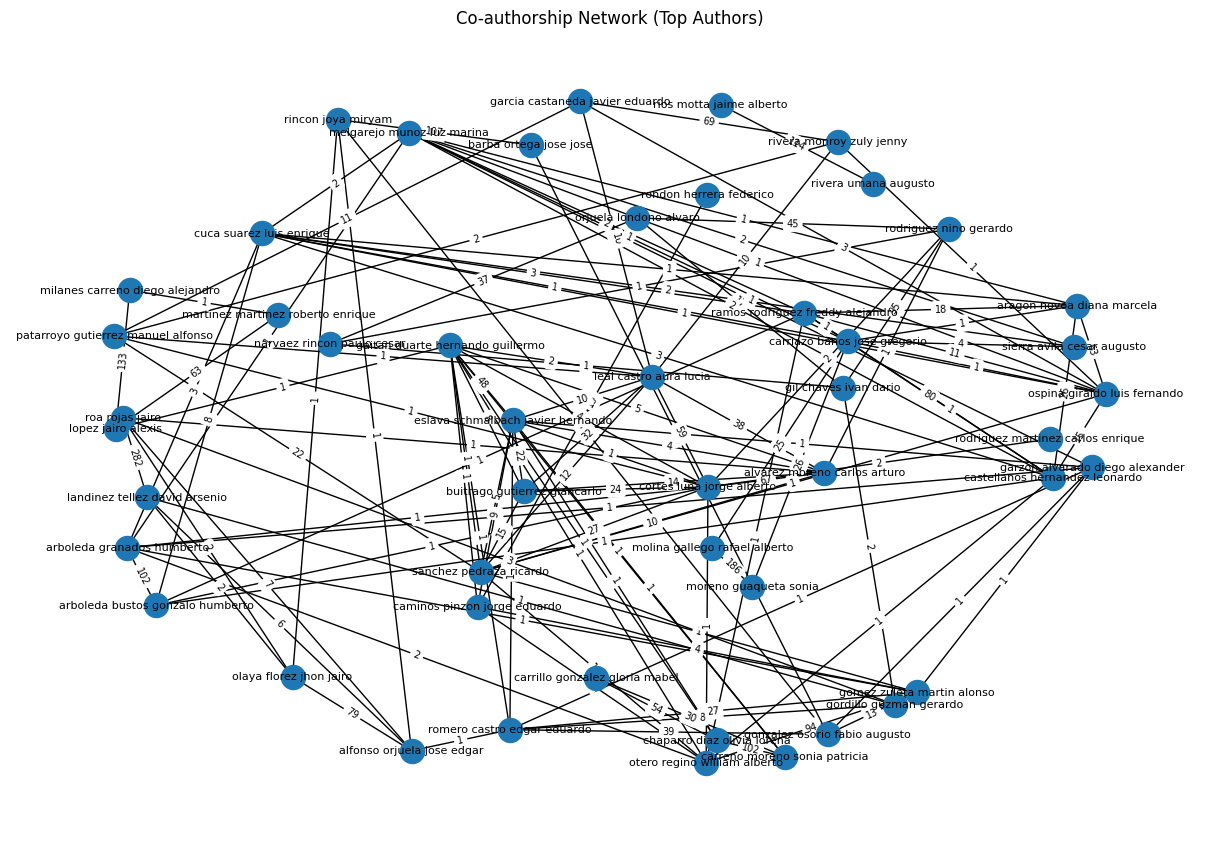

In [7]:
TOP_N = 50 

top_authors = {
    a for a, _ in author_counts.most_common(TOP_N)
}

print(f"Top authors selected: {len(top_authors)}")

filtered_transactions_top = transactions_filtered.apply(
    lambda authors: [a for a in authors if a in top_authors]
)

filtered_transactions_top = filtered_transactions_top[
    filtered_transactions_top.apply(len) > 1
]

print(f"Filtered transactions: {len(filtered_transactions_top)}")

cooccurrence = Counter()

for trans in filtered_transactions_top:
    for pair in combinations(trans, 2):
        cooccurrence[tuple(sorted(pair))] += 1

G = nx.Graph()

for (a1, a2), w in cooccurrence.items():
    G.add_edge(a1, a2, weight=w)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(
    G,
    k=3,        
    iterations=50, 
    seed=42
)

nx.draw(G, pos, with_labels=True, node_size=300, font_size=8)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Co-authorship Network (Top Authors)")
plt.show()

### 2.4. Co-authorship network - most relevant authors per faculty

This visualization presents three separate co-authorship networks, one for each selected faculty: Medicina, Ingeniería, and Ciencias. Each graph is constructed by filtering the dataset to include only publications from the corresponding faculty, then identifying the most frequent authors within that subset. Nodes represent authors, and edges indicate co-authorship relationships, with edge labels showing the number of shared publications. By isolating each faculty, the structure of collaboration becomes clearer, allowing comparison of network density, central authors, and collaboration patterns across disciplines. This approach highlights how research collaboration varies depending on the academic domain.


Processing faculty: medicina
Rows: 18597
Nodes: 29, Edges: 73

Processing faculty: ingeniería
Rows: 14670
Nodes: 39, Edges: 94

Processing faculty: ciencias
Rows: 31727
Nodes: 30, Edges: 55


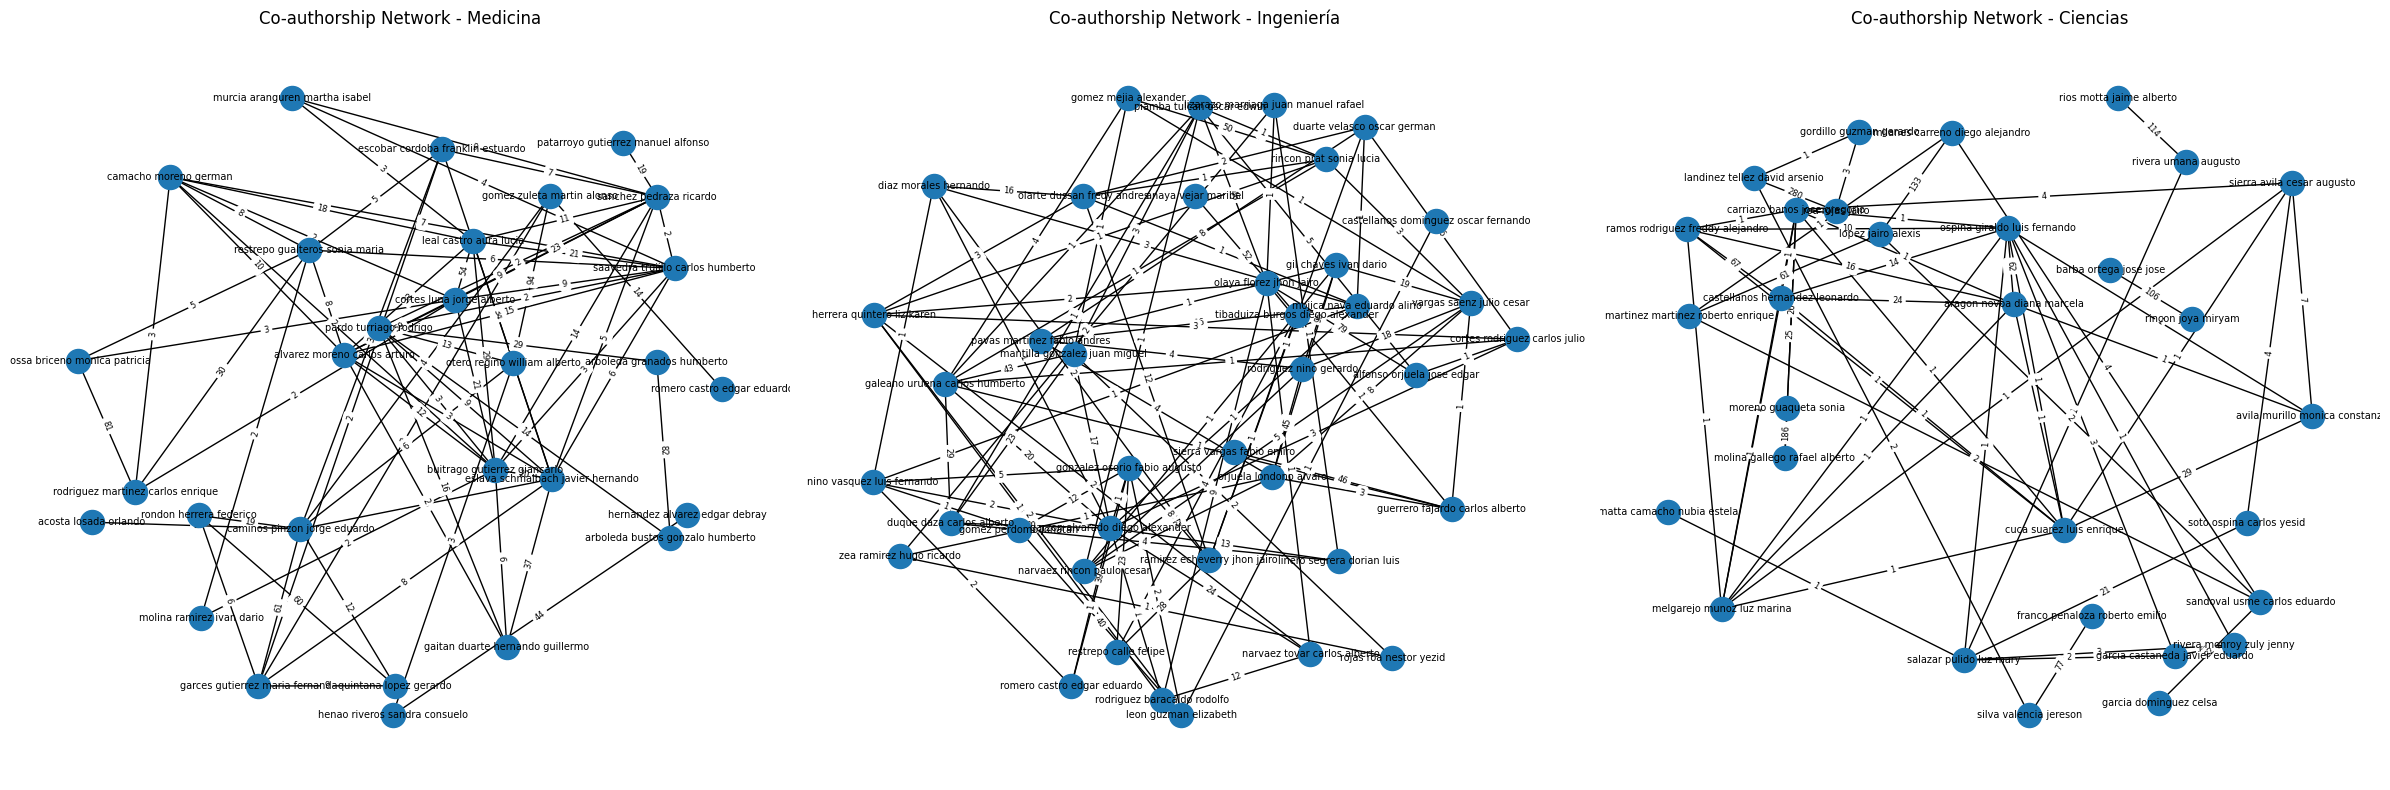

In [8]:
df['faculty_clean'] = df['faculty'].str.lower().str.strip()

FACULTY_CONFIG = {
    'medicina': {'top_n': 30, 'min_weight': 2, 'k': 4},
    'ingeniería': {'top_n': 40, 'min_weight': 1, 'k': 3},
    'ciencias': {'top_n': 30, 'min_weight': 1, 'k': 3}
}

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (faculty, config) in enumerate(FACULTY_CONFIG.items()):

    print(f"\nProcessing faculty: {faculty}")

    df_faculty = df[df['faculty_clean'] == faculty]

    print(f"Rows: {len(df_faculty)}")

    if df_faculty.empty:
        print(f"⚠️ No data for {faculty}")
        continue

    transactions = df_faculty['active_coauthors'].apply(parse_coauthors)
    transactions = transactions[transactions.apply(len) > 1]

    all_authors = [a for trans in transactions for a in trans]
    author_counts = Counter(all_authors)

    top_authors = {
        a for a, _ in author_counts.most_common(config['top_n'])
    }

    transactions_top = transactions.apply(
        lambda authors: [a for a in authors if a in top_authors]
    )

    transactions_top = transactions_top[
        transactions_top.apply(len) > 1
    ]

    cooccurrence = Counter()

    for trans in transactions_top:
        for pair in combinations(trans, 2):
            cooccurrence[tuple(sorted(pair))] += 1

    G = nx.Graph()

    for (a1, a2), w in cooccurrence.items():
        if w >= config['min_weight']:
            G.add_edge(a1, a2, weight=w)

    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

    if G.number_of_nodes() == 0:
        continue

    ax = axes[i]

    pos = nx.spring_layout(G, k=config['k'], seed=42)

    nx.draw(G, pos, ax=ax, with_labels=True, node_size=300, font_size=7)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax)

    ax.set_title(f"Co-authorship Network - {faculty.capitalize()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 3. Apriori

The Apriori algorithm is applied to identify frequent combinations of authors. It works by iteratively generating candidate itemsets and evaluating their support. While simple and interpretable, Apriori can be computationally expensive for large datasets.

In [9]:
frequent_itemsets_apriori = apriori(
    df_encoded,
    min_support=0.001,
    use_colnames=True
)

frequent_itemsets_apriori.head()

,support,itemsets
0,0.001274,(acevedo osorio alvaro)
1,0.001672,(acosta forero bernarda jinneth)
2,0.005017,(acosta losada orlando)
3,0.001991,(afanador tellez german)
4,0.003345,(agamez pertuz yazmin yaneth)


### 3.1. Distribution of Frequent Itemset Sizes

This visualization shows the distribution of frequent itemsets according to their size, where each size represents the number of authors collaborating together in a publication. By analyzing how many itemsets exist for each group size, it is possible to understand whether collaborations tend to occur mainly between pairs of researchers or within larger groups.

length
1    635
2    272
3     25
Name: count, dtype: int64


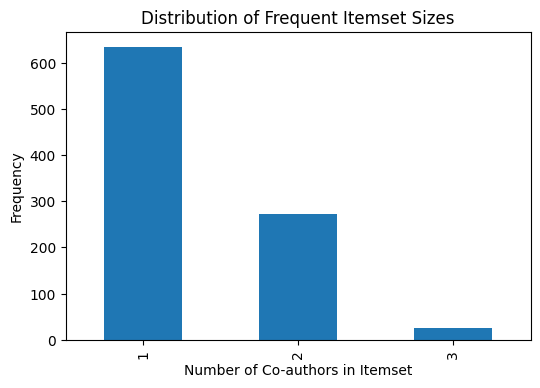

In [10]:
frequent_itemsets_apriori['length'] = frequent_itemsets_apriori['itemsets'].apply(len)

itemset_distribution = frequent_itemsets_apriori['length'].value_counts().sort_index()

print(itemset_distribution)

plt.figure(figsize=(6,4))
itemset_distribution.plot(kind='bar')

plt.title("Distribution of Frequent Itemset Sizes")
plt.xlabel("Number of Co-authors in Itemset")
plt.ylabel("Frequency")
plt.show()

The distribution shows a strong dominance of single-author itemsets (635), followed by a significantly smaller number of pairwise collaborations (272), and very few groups of three authors (25). This indicates that while individual productivity is high, meaningful collaboration patterns are mostly limited to pairs, with very few stable multi-author teams. The sharp drop from pairs to triples suggests that larger research groups are rare and likely represent highly specialized or tightly coordinated collaborations rather than the norm.

### 3.2. Top Co-authorship Groups (≥ 3 Authors)

This table highlights the most relevant co-authorship groups composed of three or more authors, ranked by support. These itemsets represent groups of researchers who frequently collaborate together across multiple publications, providing insight into stable research teams within the dataset.

In [11]:
top_groups = frequent_itemsets_apriori[
    frequent_itemsets_apriori['itemsets'].apply(lambda x: len(x) >= 2)
].sort_values(by='support', ascending=False)

top_groups.head(10)

,support,itemsets,length
832,0.022458,"(roa rojas jairo, landinez tellez david arsenio)",2
859,0.014812,"(molina gallego rafael alberto, moreno guaquet...",2
840,0.010592,"(milanes carreno diego alejandro, lopez jairo ...",2
897,0.009079,"(rios motta jaime alberto, rivera umana augusto)",2
683,0.008521,"(rincon joya miryam, barba ortega jose jose)",2
713,0.008123,"(chaparro diaz olivia lorena, carreno moreno s...",2
668,0.008123,"(arboleda bustos gonzalo humberto, arboleda gr...",2
798,0.007566,"(rodriguez nino gerardo, gil chaves ivan dario)",2
813,0.007486,"(gomez zuleta martin alonso, otero regino will...",2
790,0.006530,"(garcia dominguez celsa, sandoval usme carlos ...",2


### 3.3. Co-authorship Network Based on Frequent Itemsets (Apriori)

This network is constructed using only statistically significant co-authorship patterns derived from Apriori frequent itemsets. Nodes represent authors, while edges connect authors who appear together in frequent itemsets, with edge weights reflecting the strength of their association based on support values.

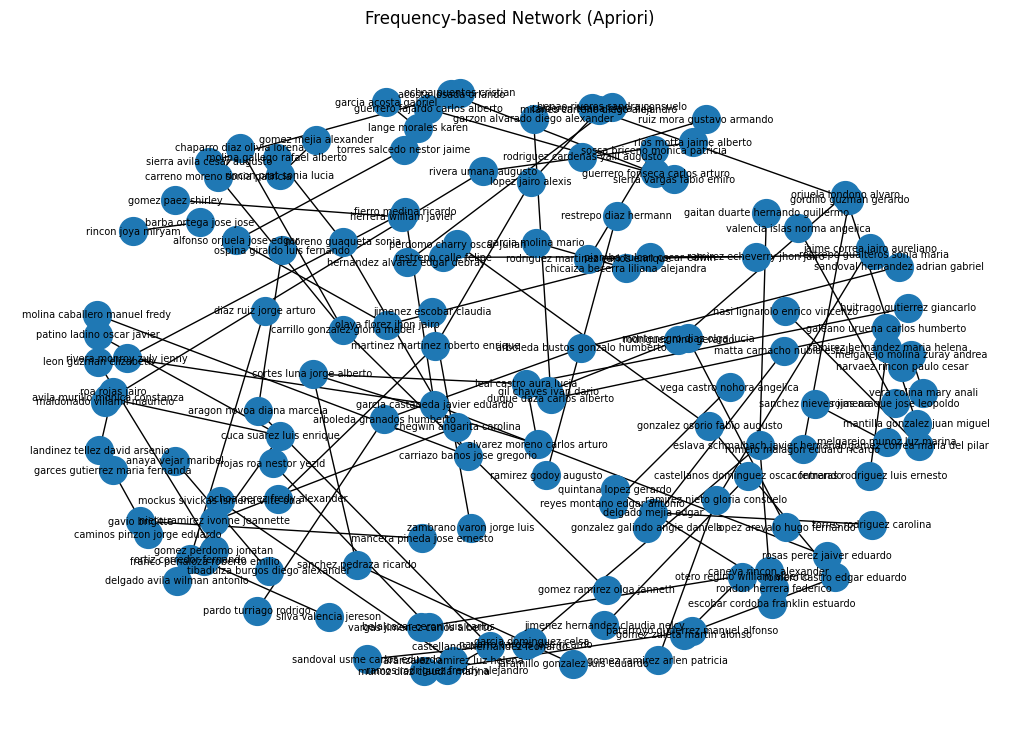

In [12]:
strong_itemsets = frequent_itemsets_apriori[
    (frequent_itemsets_apriori['support'] > 0.002) &
    (frequent_itemsets_apriori['length'] >= 2)
]

G_rules = nx.Graph()

for _, row in strong_itemsets.iterrows():
    authors = list(row['itemsets'])
    
    for pair in combinations(authors, 2):
        G_rules.add_edge(pair[0], pair[1], weight=row['support'])

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G_rules, seed=42)

nx.draw(G_rules, pos, with_labels=True, node_size=400, font_size=7)

plt.title("Frequency-based Network (Apriori)")
plt.show()

Unlike a standard co-occurrence network, this graph highlights only meaningful and recurring collaboration patterns, filtering out noise and incidental connections. As a result, the network emphasizes stronger and more reliable relationships, revealing core collaboration structures within the research community. This provides a more robust representation of the collaboration landscape, grounded in statistical significance rather than raw frequency alone.

# 4. FP-Growth

FP-Growth is applied as a more efficient alternative to Apriori. It uses a compressed tree structure to identify frequent patterns without generating all candidate combinations. This results in significantly faster execution while producing equivalent results.

In [13]:
frequent_itemsets_fp = fpgrowth(
    df_encoded,
    min_support=0.001,
    use_colnames=True
)
frequent_itemsets_fp.head()

,support,itemsets
0,0.002787,(lopez kleine liliana)
1,0.002469,(giraldo henao ramon)
2,0.001035,(carvajal martinez jorge enrique)
3,0.003265,(lange morales karen)
4,0.003185,(garcia acosta gabriel)


In [14]:
frequent_itemsets_fp['length'] = frequent_itemsets_fp['itemsets'].apply(len)
size_dist_fp = frequent_itemsets_fp['length'].value_counts().sort_index()
print(size_dist_fp)


length
1    635
2    272
3     25
Name: count, dtype: int64


The frequent itemsets generated by Apriori and FP-Growth are equivalent. This is expected because both algorithms are designed to identify the same set of frequent patterns given the same dataset and support threshold. The key difference lies in their approach: Apriori uses a candidate-generation strategy, which can be computationally expensive, while FP-Growth employs a compressed tree structure (FP-tree) to mine patterns more efficiently. As a result, FP-Growth typically achieves better performance without affecting the correctness or completeness of the extracted itemsets.

**Min support 0.001**

The minimum support was set to 0.001, which is considered a low threshold. This choice allows capturing infrequent but potentially meaningful collaboration patterns, which is important in academic datasets where strong collaborations may not occur frequently. A higher support value would filter out these patterns, while a lower value could introduce noise and reduce the interpretability of the results.

# 5. Generate rules

This step generates association rules from the frequent itemsets. Each rule represents a relationship between sets of authors. The rules are filtered using the lift metric, which measures how much stronger the association is compared to random chance.

In [15]:
rules = association_rules(
    frequent_itemsets_fp,
    metric="lift",
    min_threshold=1.2
)

print(rules.head())

                    antecedents                      consequents  \
0         (lange morales karen)          (garcia acosta gabriel)   
1       (garcia acosta gabriel)            (lange morales karen)   
2    (zea ramirez hugo ricardo)     (ramirez franco jose herney)   
3  (ramirez franco jose herney)       (zea ramirez hugo ricardo)   
4     (blanco jimenez carolina)  (daza velasquez carlos enrique)   

   antecedent support  consequent support   support  confidence        lift  \
0            0.003265            0.003185  0.002469    0.756098  237.357927   
1            0.003185            0.003265  0.002469    0.775000  237.357927   
2            0.004221            0.002230  0.001274    0.301887  135.385445   
3            0.002230            0.004221  0.001274    0.571429  135.385445   
4            0.001672            0.003026  0.001195    0.714286  236.033835   

   representativity  leverage  conviction  zhangs_metric   jaccard  certainty  \
0               1.0  0.002458    4.

### 5.1. Top rules

The rules are ranked based on their importance using lift, confidence, and support. Lift is prioritized as it reflects the strength of the association beyond random chance. The top 10 rules represent the most significant collaboration patterns in the dataset.

In [16]:
rules_sorted = rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
)

top_10 = rules_sorted.head(10)

top_10[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
284,(nunez alarcon daniel),(serrano rodriguez diana marcela),0.001115,1.000000,784.812500
285,(serrano rodriguez diana marcela),(nunez alarcon daniel),0.001115,0.875000,784.812500
618,(gil hernandez franklin gerly),(viveros vigoya mara),0.001115,1.000000,738.647059
619,(viveros vigoya mara),(gil hernandez franklin gerly),0.001115,0.823529,738.647059
692,(arango calderon sandra liliana),(garcia castro liz angela),0.001035,0.928571,728.754464
693,(garcia castro liz angela),(arango calderon sandra liliana),0.001035,0.812500,728.754464
156,(cuervo prado paola andrea),(orozco lopez fabian),0.001593,0.952381,569.478458
157,(orozco lopez fabian),(cuervo prado paola andrea),0.001593,0.952381,569.478458
560,(pineda jaimes jorge arturo),(colmenares montanez julio esteban),0.001274,1.000000,465.074074
561,(colmenares montanez julio esteban),(pineda jaimes jorge arturo),0.001274,0.592593,465.074074


### 5.2. Strongest association rules ranked by lift

This chart displays the strongest association rules ranked by lift. Lift measures how much more likely two sets of authors collaborate compared to random chance, making it a key metric for identifying meaningful relationships.

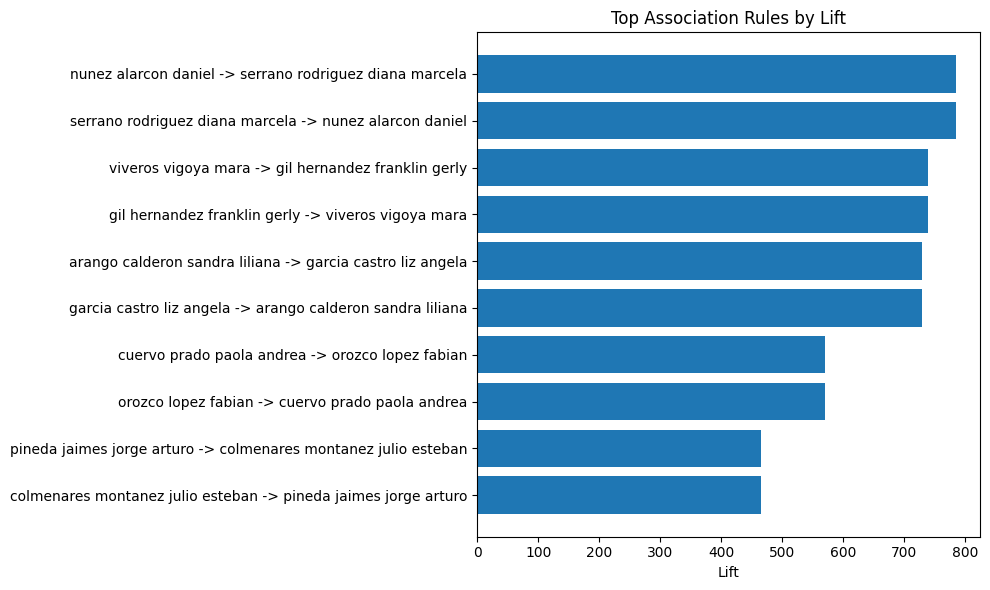

In [21]:
top_rules = rules.sort_values(by="lift", ascending=False).head(10)

rule_labels = [
    f"{', '.join(list(row['antecedents']))} -> {', '.join(list(row['consequents']))}"
    for _, row in top_rules.iterrows()
]

plt.figure(figsize=(10, 6))

plt.barh(rule_labels, top_rules['lift'])

plt.xlabel("Lift")
plt.title("Top Association Rules by Lift")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretation of Top Association Rules

The top association rules reveal strong and consistent collaboration patterns between specific authors. High lift values indicate that these co-authorship relationships occur significantly more often than expected by chance, suggesting stable research partnerships.

Most rules show high confidence, meaning that when a group of authors appears, the associated co-authors are very likely to also be present. This reflects tightly connected research groups.

Additionally, many of these rules involve pairs of authors, reinforcing the earlier observation that collaboration in this dataset is primarily driven by small groups rather than large teams.

### 5.3. Support vs Confidence of Association Rules

This scatter plot visualizes the relationship between support and confidence for all generated rules. It helps identify rules that are both frequent (high support) and reliable (high confidence), enabling better selection of meaningful collaboration patterns.

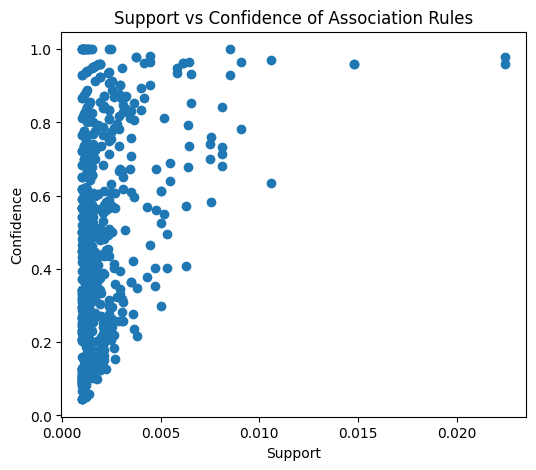

In [18]:
plt.figure(figsize=(6,5))

plt.scatter(
    rules['support'],
    rules['confidence']
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence of Association Rules")

plt.show()

### 5.4. Faculty-Based Analysis of Association Rules

An analysis of author affiliations shows that most of the strongest association rules occur between authors belonging to the same faculty. This suggests that collaboration is largely driven by disciplinary proximity, as researchers within the same academic field are more likely to co-author publications.

In [25]:
author_faculty = {}

for _, row in df.iterrows():
    faculty = str(row['faculty']).lower().strip()
    authors = parse_coauthors(row['active_coauthors'])
    
    for a in authors:
        if a not in author_faculty:
            author_faculty[a] = []
        author_faculty[a].append(faculty)

author_main_faculty = {
    a: Counter(facs).most_common(1)[0][0]
    for a, facs in author_faculty.items()
}

def get_faculties(authors):
    return [author_main_faculty.get(a, "unknown") for a in authors]

top_10 = rules_sorted.head(10).copy()

top_10['antecedent_faculty'] = top_10['antecedents'].apply(get_faculties)
top_10['consequent_faculty'] = top_10['consequents'].apply(get_faculties)

top_10[['antecedents', 'consequents', 'antecedent_faculty', 'consequent_faculty']]

,antecedents,consequents,antecedent_faculty,consequent_faculty
284,(nunez alarcon daniel),(serrano rodriguez diana marcela),[ciencias],[ciencias]
285,(serrano rodriguez diana marcela),(nunez alarcon daniel),[ciencias],[ciencias]
618,(gil hernandez franklin gerly),(viveros vigoya mara),[ciencias humanas],[ciencias humanas]
619,(viveros vigoya mara),(gil hernandez franklin gerly),[ciencias humanas],[ciencias humanas]
692,(arango calderon sandra liliana),(garcia castro liz angela),[artes],[artes]
693,(garcia castro liz angela),(arango calderon sandra liliana),[artes],[artes]
156,(cuervo prado paola andrea),(orozco lopez fabian),[ciencias],[ciencias]
157,(orozco lopez fabian),(cuervo prado paola andrea),[ciencias],[ciencias]
560,(pineda jaimes jorge arturo),(colmenares montanez julio esteban),[ingeniería],[ingeniería]
561,(colmenares montanez julio esteban),(pineda jaimes jorge arturo),[ingeniería],[ingeniería]



This behavior is consistent with the previously observed faculty-specific co-authorship networks, where dense clusters of collaboration appear within each academic domain. Therefore, the association rules are not random but reflect underlying organizational and disciplinary structures in the dataset.